In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# 🧪 Part 1 — Data Loading & Inspection

In [55]:
# Import the dataset into a pandas DataFrame.
df = pd.read_csv('global_air_pollution_data.csv')
df.info()

# total number of rows
len(df)

# Number of columns
df.columns.size

df.shape # returns a tuple (row, column)

# List all column names and their data types.
df.dtypes

# Identify columns with missing values.
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   country_name        23036 non-null  object
 1   city_name           23462 non-null  object
 2   aqi_value           23463 non-null  int64 
 3   aqi_category        23463 non-null  object
 4   co_aqi_value	       23463 non-null  int64 
 5   co_aqi_category     23463 non-null  object
 6   ozone_aqi_value     23463 non-null  int64 
 7   ozone_aqi_category  23463 non-null  object
 8   no2_aqi_value       23463 non-null  int64 
 9   no2_aqi_category    23463 non-null  object
 10  pm2.5_aqi_value     23463 non-null  int64 
 11  pm2.5_aqi_category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


country_name          427
city_name               1
aqi_value               0
aqi_category            0
co_aqi_value\t          0
co_aqi_category         0
ozone_aqi_value         0
ozone_aqi_category      0
no2_aqi_value           0
no2_aqi_category        0
pm2.5_aqi_value         0
pm2.5_aqi_category      0
dtype: int64

# 🧹 Part 2 — Data Cleaning

## Q6: Check whether there are duplicate rows in the dataset.

In [24]:
# Duplicates
df.duplicated().any()

#or
df.duplicated().sum()

np.int64(0)

## Q7: Determine how many unique countries exist in the dataset.

In [32]:
# Unique countries
len(df['country_name'].unique())

# Or
df['country_name'].unique().size

176

## Q8: Determine how many unique cities exist in the dataset.

In [34]:
# Unique cities
df['city_name'].unique().size

23463

## Q9: Check whether any pollution AQI values are negative or unrealistic.

In [47]:
# Unrealistic values are those over 500 
(df['aqi_value'] < 0) .any()
(df['aqi_value'] > 500) .any()

((df[['aqi_value', 'ozone_aqi_value', 'pm2.5_aqi_value']] < 0) | (df[['aqi_value', 'ozone_aqi_value', 'pm2.5_aqi_value']] > 500)) .any() # returns false meaning aqi values are realistic and none is negative


aqi_value          False
ozone_aqi_value    False
pm2.5_aqi_value    False
dtype: bool

# 📊 Part 3 — Exploratory Data Analysis

## Q10: Calculate the average AQI value for each country.

In [104]:
# Avg aqi value per country
avg_aqi_per_country = df.groupby('country_name')['aqi_value'].mean().reset_index(name = 'avg_aqi_value').round(4).sort_values(by = 'avg_aqi_value', ascending = False)
avg_aqi_per_country

,country_name,avg_aqi_value
126,Republic of Korea,421.0000
11,Bahrain,188.0000
98,Mauritania,179.0000
116,Pakistan,178.7883
163,United Arab Emirates,163.6667
...,...,...
19,Bolivia (Plurinational State of),23.7879
68,Iceland,23.0000
95,Maldives,19.0000
142,Solomon Islands,18.0000


## Q11: Identify the top 10 cities with the highest AQI values.

In [69]:
# top 10 cities aqi levels
top_cities_aqi_value = df[['city_name', 'aqi_value']].sort_values(by = 'aqi_value', ascending = False).head(10)
top_cities_aqi_value

,city_name,aqi_value
2773,Bisalpur,500
4749,Ujhani,500
2502,Jodhpur,500
2473,Kanina,500
5139,Delhi,500
5156,Durango,500
5266,Nohar,500
5475,Chhachhrauli,500
5571,Sisauli,500
2297,Phalodi,500


## Q12: Determine which country has the highest average AQI value.

In [88]:
# Country with highest avg aqi value
country_highest_avg_aqi_value = df. groupby('country_name')['aqi_value'].mean().reset_index(name = 'avg_aqi_value').sort_values(by = 'avg_aqi_value', ascending = False).head(1)
country_highest_avg_aqi_value

# Alternative 2
country_highest_avg_aqi_value_1 = df. groupby('country_name')['aqi_value'].mean().reset_index(name = 'avg_aqi_value')
country_highest_avg_aqi_value_1 = country_highest_avg_aqi_value_1.loc[country_highest_avg_aqi_value_1['avg_aqi_value'].idxmax()]
country_highest_avg_aqi_value_1

country_name     Republic of Korea
avg_aqi_value                421.0
Name: 126, dtype: object

# 📈 Part 4 — Visualization

## Q15: Bar chart showing Top 10 most polluted cities (based on AQI value)

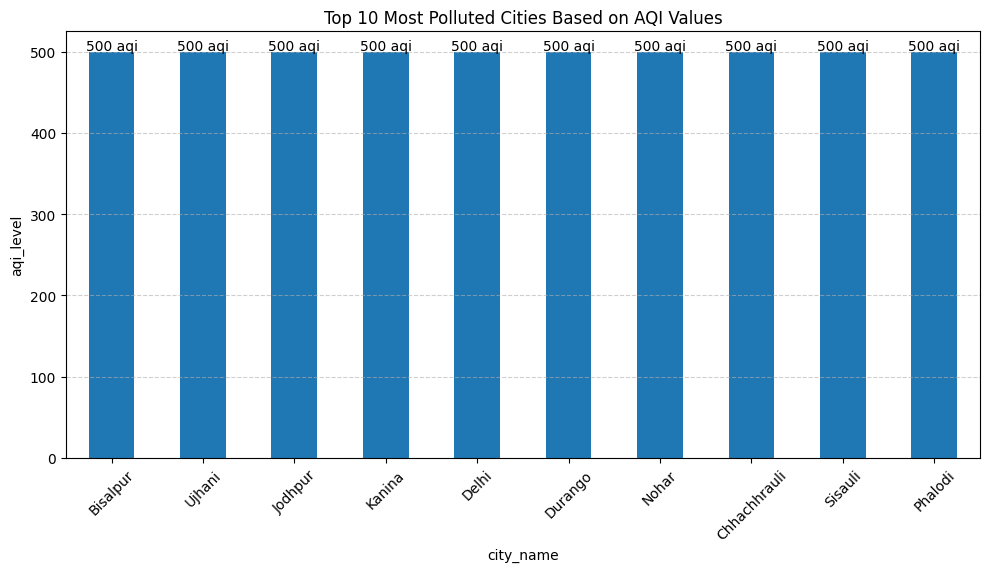

In [102]:
top_cities_aqi_value.plot(kind = 'bar', x = 'city_name', y = 'aqi_value', figsize = (10,6), legend = False)
plt.title('Top 10 Most Polluted Cities Based on AQI Values')
plt.ylabel('aqi_level')
plt.tight_layout()
plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)
plt.xticks(rotation = 45)

for city, val in enumerate(top_cities_aqi_value['aqi_value']):
    plt.text(city, val + 2, f'{val} aqi', ha = 'center')
plt.show()

## Q16: Bar chart showing Average AQI by country

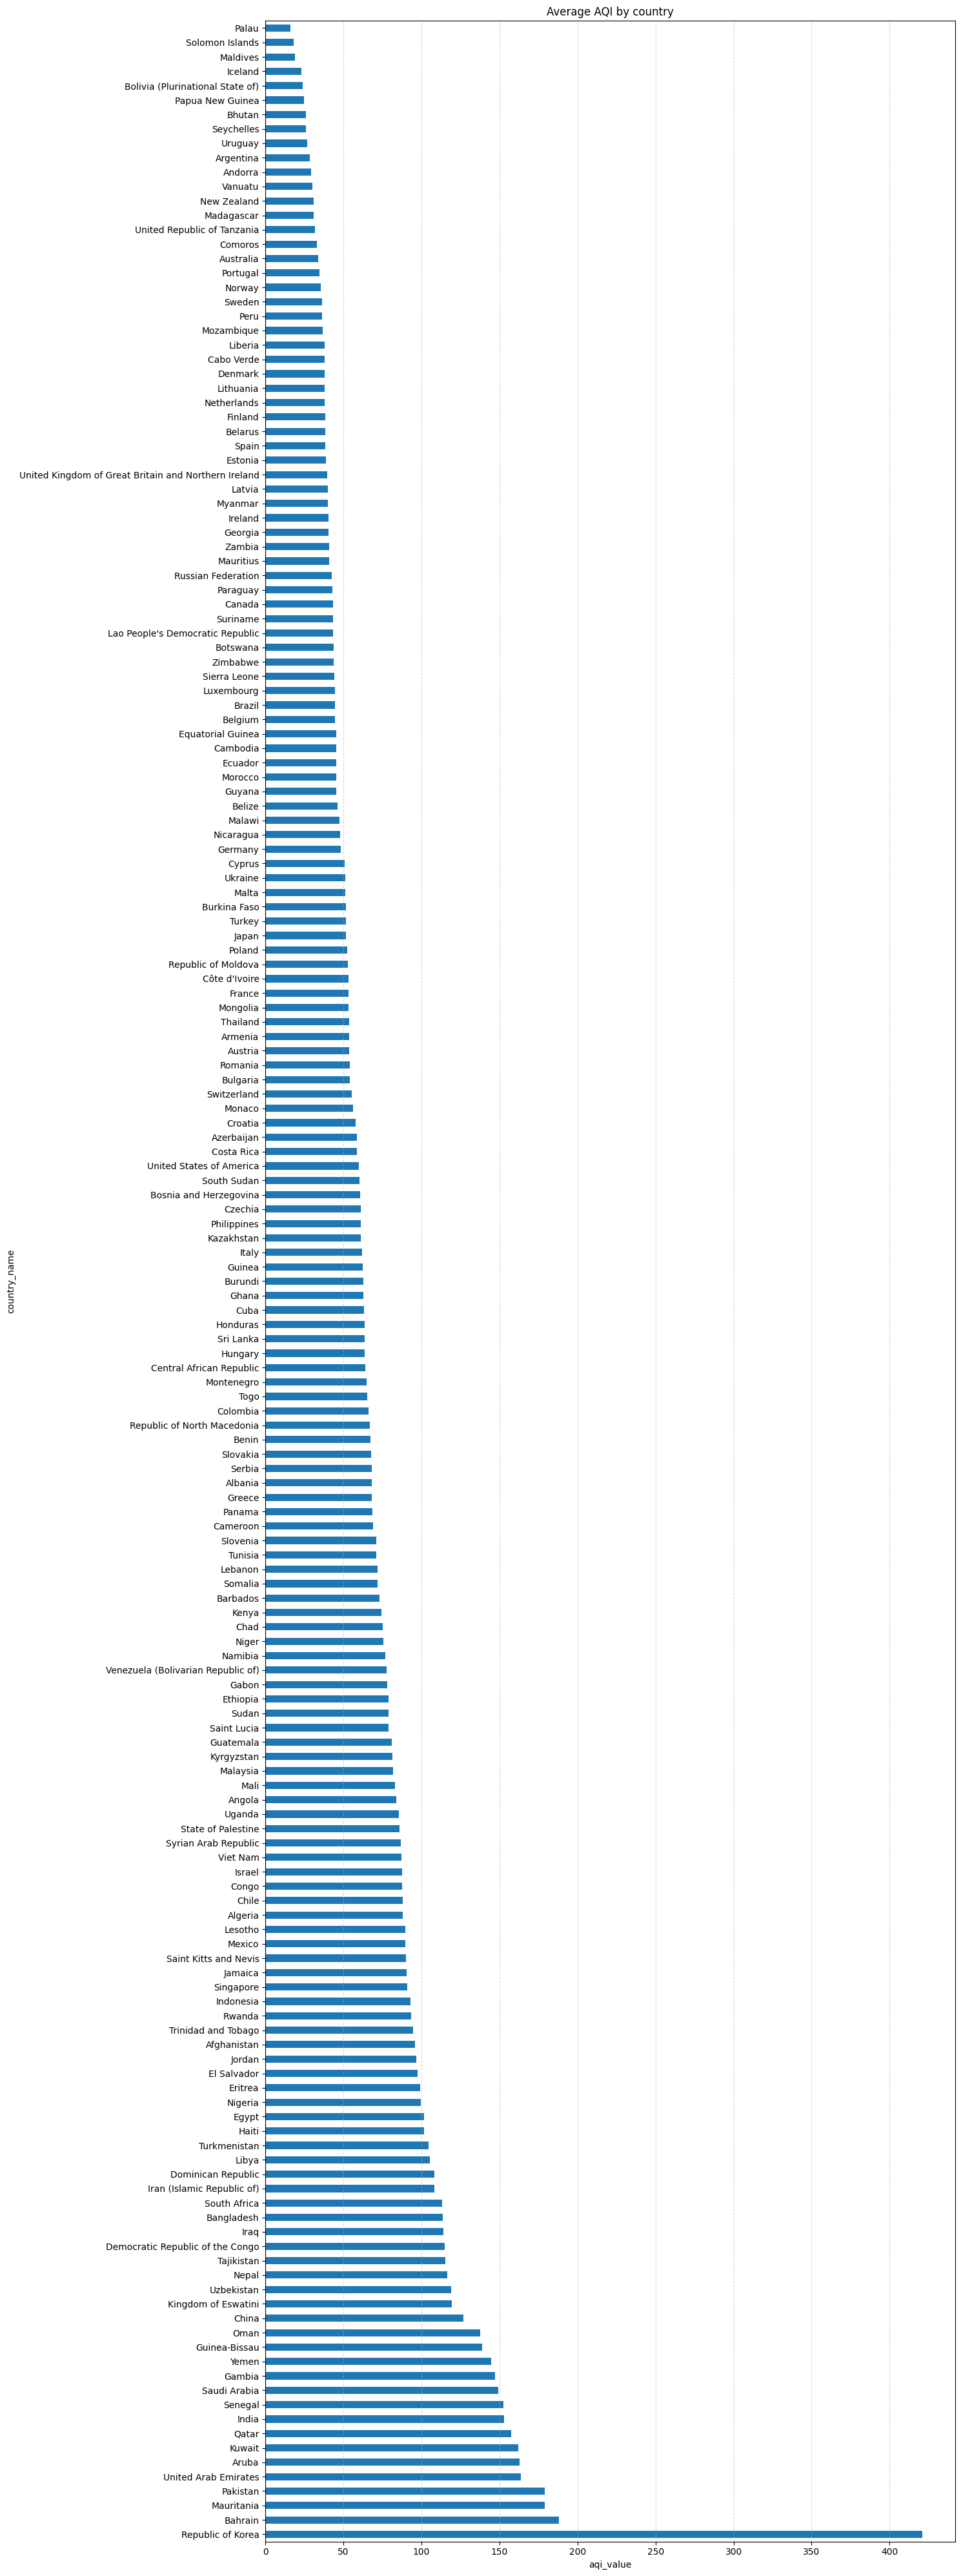

In [123]:
avg_aqi_per_country = df.groupby('country_name')['aqi_value'].mean().reset_index(name = 'avg_aqi_value').round(4).sort_values(by = 'avg_aqi_value', ascending = False)
avg_aqi_per_country

# Plotting
avg_aqi_per_country_20.plot(kind = 'barh', figsize = (15,40), x = 'country_name', y = 'avg_aqi_value', legend = False)
plt.title('Average AQI by country')
plt.xlabel('aqi_value')
plt.tight_layout()
plt.grid(axis = 'x', linestyle = '--', alpha = 0.5)
plt.show()